# Wilcoxon signed-rank test (paired samples)

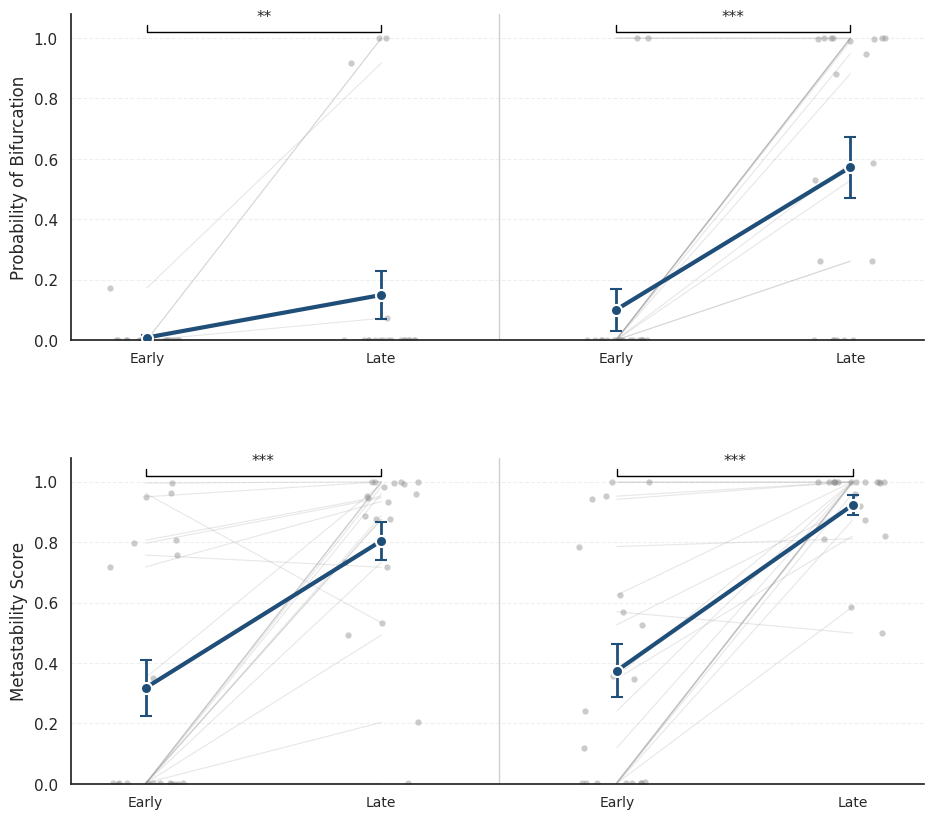

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# =======================
# Self-contained setup
# =======================
repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")

conditions = [
    ("Passive", "early"),
    ("Passive", "late"),
    ("Active", "early"),
    ("Active", "late"),
]

map_task = {"Passive": "no-report", "Active": "report"}
condition_order_plot = [
    "no-report-early",
    "no-report-late",
    "report-early",
    "report-late",
]

x_lookup = {cond: i for i, cond in enumerate(condition_order_plot)}
mean_color = "#1f4e78"  # deep navy for group-level trajectory
PANEL_GAP = 0.36  # <-- Increase/decrease this to control space between top and bottom panels

# =======================
# Load bifurcation probability
# =======================
bif_dfs = []
for task, period in conditions:
    base_path = repo_root / f"Fit_{task}_{period}_19blocks"
    csv_path = base_path / "BifurcationProbability_AllModels" / "bifurcation_probabilities.csv"

    df = pd.read_csv(csv_path, index_col=0).copy()
    if "probability_of_bifurcation" in df.columns:
        df = df.rename(columns={"probability_of_bifurcation": "bifurcation_prob"})
    if "bifurcation_prob" not in df.columns:
        raise ValueError(f"Missing bifurcation column in {csv_path}")

    df["bifurcation_prob"] = df["bifurcation_prob"].fillna(0)
    df["SubID"] = df.index.astype(str)
    df["task"] = task
    df["period"] = period
    df["task_plot"] = df["task"].map(map_task)
    df["condition_plot"] = df["task_plot"] + "-" + df["period"]
    bif_dfs.append(df)

bif_data = pd.concat(bif_dfs, ignore_index=True)

# =======================
# Load metastability score
# =======================
meta_dfs = []
for task, period in conditions:
    csv_path = repo_root / f"Fit_{task}_{period}" / "metastability_scores_bestmodel.csv"

    df = pd.read_csv(csv_path, index_col=0).copy()
    if "metastability_score" not in df.columns:
        raise ValueError(f"Missing metastability_score column in {csv_path}")

    df["SubID"] = df.index.astype(str)
    df["task"] = task
    df["period"] = period
    df["task_plot"] = df["task"].map(map_task)
    df["condition_plot"] = df["task_plot"] + "-" + df["period"]
    meta_dfs.append(df)

meta_data = pd.concat(meta_dfs, ignore_index=True)

# =======================
# Statistics helpers
# =======================
def paired_permutation_p(df, value_col, task, n_permutations=10000, seed=0):
    e = df[(df.task == task) & (df.period == "early")].set_index("SubID")
    l = df[(df.task == task) & (df.period == "late")].set_index("SubID")

    common = e.index.intersection(l.index)
    e_vals = e.loc[common, value_col]
    l_vals = l.loc[common, value_col]

    valid = ~(e_vals.isna() | l_vals.isna())
    e_vals = e_vals[valid].to_numpy()
    l_vals = l_vals[valid].to_numpy()

    if len(e_vals) < 2:
        return np.nan

    obs_diff = e_vals.mean() - l_vals.mean()
    pair_diffs = e_vals - l_vals

    rng = np.random.default_rng(seed)
    perm_diffs = np.empty(n_permutations)

    for i in range(n_permutations):
        swap_mask = rng.random(len(pair_diffs)) < 0.5
        permuted_diffs = np.where(swap_mask, -pair_diffs, pair_diffs)
        perm_diffs[i] = permuted_diffs.mean()

    return np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))


def stars_or_p(p):
    if not np.isfinite(p):
        return "n/a"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return f"p={p:.3f}"


def add_xlabels(ax):
    # Keep only Early/Late labels; major group text is intentionally removed
    ax.set_xticks([0, 1, 2, 3], ["Early", "Late", "Early", "Late"])
    ax.tick_params(axis="x", pad=2, labelsize=10)


def draw_significance_bracket(ax, x1, x2, y, text, tick=0.02, lw=1.0):
    # Thin bracket with short downward ticks at both ends
    ax.plot([x1, x1, x2, x2], [y, y - tick, y - tick, y], color="black", lw=lw, clip_on=False)
    ax.text((x1 + x2) / 2, y + tick * 0.15, text, ha="center", va="bottom", fontsize=11)


def plot_panel(ax, df, value_col, y_label):
    # Individual paired trajectories: muted gray to reduce clutter
    for task in ["Passive", "Active"]:
        early = df[(df.task == task) & (df.period == "early")]
        late = df[(df.task == task) & (df.period == "late")]

        for sub in set(early.SubID).intersection(late.SubID):
            y1 = early.loc[early.SubID == sub, value_col].values[0]
            y2 = late.loc[late.SubID == sub, value_col].values[0]
            x1 = x_lookup[f"{map_task[task]}-early"]
            x2 = x_lookup[f"{map_task[task]}-late"]
            ax.plot([x1, x2], [y1, y2], color="#a0a0a0", alpha=0.25, lw=0.8, zorder=1)

    # Individual points in matching muted tone
    sns.stripplot(
        data=df,
        x="condition_plot",
        y=value_col,
        order=condition_order_plot,
        jitter=0.16,
        size=4.5,
        alpha=0.45,
        color="#8d8d8d",
        ax=ax,
        zorder=2,
    )

    # Group means and SEM
    stats = (
        df.groupby("condition_plot")[value_col]
        .agg(["mean", "sem"])
        .reindex(condition_order_plot)
    )

    # Mean trajectory inside each task block
    ax.plot([0, 1], [stats.loc["no-report-early", "mean"], stats.loc["no-report-late", "mean"]],
            color=mean_color, lw=3.0, zorder=3)
    ax.plot([2, 3], [stats.loc["report-early", "mean"], stats.loc["report-late", "mean"]],
            color=mean_color, lw=3.0, zorder=3)

    ax.errorbar(
        x=np.arange(4),
        y=stats["mean"],
        yerr=stats["sem"],
        fmt="o",
        color=mean_color,
        markerfacecolor=mean_color,
        markeredgecolor="white",
        markeredgewidth=1.5,
        capsize=4,
        markersize=8,
        lw=2.0,
        zorder=4,
    )

    # Subtle horizontal gridlines for value reading
    ax.grid(axis="y", alpha=0.3, linestyle="--", linewidth=0.8)
    ax.set_axisbelow(True)

    # Dynamic upper bound near normalized scale while leaving headroom for brackets
    data_max = np.nanmax(df[value_col].to_numpy())
    upper = max(1.0, data_max * 1.08)
    ax.set_ylim(0, upper)

    # Significance brackets, thinner and closer to data ceiling
    p_passive = paired_permutation_p(df, value_col, "Passive")
    p_active = paired_permutation_p(df, value_col, "Active")
    tick = 0.02 * upper
    y_bracket = min(upper * 0.965, data_max + 0.04 * upper)

    draw_significance_bracket(ax, 0, 1, y_bracket, stars_or_p(p_passive), tick=tick, lw=1.0)
    draw_significance_bracket(ax, 2, 3, y_bracket, stars_or_p(p_active), tick=tick, lw=1.0)

    add_xlabels(ax)
    ax.axvline(1.5, color="#cfcfcf", lw=1.0, zorder=0)  # visual separator between task groups

    ax.set_ylabel(y_label)
    ax.set_xlabel("")
    sns.despine(ax=ax)


# =======================
# Build combined figure
# =======================
sns.set_theme(style="white")
fig, axes = plt.subplots(2, 1, figsize=(11, 10), constrained_layout=False)
fig.subplots_adjust(hspace=PANEL_GAP)

plot_panel(
    ax=axes[0],
    df=bif_data,
    value_col="bifurcation_prob",
    y_label="Probability of Bifurcation",
)

plot_panel(
    ax=axes[1],
    df=meta_data,
    value_col="metastability_score",
    y_label="Metastability Score",
)

plt.savefig('Bifurcation&Metastability_AcrossConditions_PersoModels.png')
plt.show()